**Teacher effectiveness score estimation using student outcomes and class size**

This project focuses on using data analysis and machine learning techniques to evaluate teaching effectiveness based on various academic and classroom factors.



Teacher effectiveness score estimation aims to measure how much a teacher contributes to student learning, using student outcomes (usually test scores) while accounting for class size and other factors that affect performance.


In [25]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow streamlit pyngrok

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [26]:
from google.colab import files
uploaded = files.upload()

Saving teacher_effectiveness.csv to teacher_effectiveness (1).csv


In [27]:
# 1. Load and Analyse the data
df = pd.read_csv('teacher_effectiveness.csv')



In [28]:
print(df.info()) #it gives you a quick summary of your dataset


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   avg_student_gain                964 non-null    float64
 1   class_size                      947 non-null    float64
 2   years_experience                945 non-null    float64
 3   education_level                 968 non-null    object 
 4   professional_development_hours  953 non-null    float64
 5   subject_area                    959 non-null    object 
 6   school_type                     950 non-null    object 
 7   student_demographics            950 non-null    object 
 8   teaching_method                 967 non-null    object 
 9   parental_involvement            959 non-null    object 
 10  resource_availability           957 non-null    object 
 11  effectiveness_score             954 non-null    float64
dtypes: float64(5), object(7)
memory usa

In [29]:
print(df.describe()) #critical modeling and data-cleaning decisions


       avg_student_gain  class_size  years_experience  \
count        964.000000  947.000000        945.000000   
mean          15.129199   27.349525         17.853241   
std            5.730803   10.190537          9.809522   
min            5.039453   10.000000          1.004599   
25%           10.126005   19.000000          9.139316   
50%           15.031277   28.000000         17.973276   
75%           19.993547   36.000000         26.414089   
max           24.973376   44.000000         34.981142   

       professional_development_hours  effectiveness_score  
count                      953.000000           954.000000  
mean                        49.137472             5.578841  
std                         29.011661             2.568729  
min                          0.120306             1.020750  
25%                         23.542774             3.364504  
50%                         48.561974             5.509603  
75%                         74.376090             7.771350 

In [30]:
print(df.head()) #visually inspect the dataset before analysis

   avg_student_gain  class_size  years_experience education_level  \
0          9.777584         NaN         23.162313         Masters   
1         17.958750        44.0          8.535266         Masters   
2         21.694695        21.0         16.256671    Professional   
3          5.370652        10.0         24.648786             NaN   
4         13.822033        30.0         17.780833       Bachelors   

   professional_development_hours    subject_area school_type  \
0                       85.387124        Language    Suburban   
1                       66.279244         Science    Suburban   
2                       41.372398  Social Studies       Rural   
3                       67.477452         Science       Urban   
4                       90.131052  Social Studies       Rural   

  student_demographics   teaching_method parental_involvement  \
0          Homogeneous     Project-Based               Medium   
1              Diverse       Traditional                 High   

In [31]:
# 2. Missing value analysis and data imputation
print("\nMissing Values:")
print(df.isna().sum())


Missing Values:
avg_student_gain                  36
class_size                        53
years_experience                  55
education_level                   32
professional_development_hours    47
subject_area                      41
school_type                       50
student_demographics              50
teaching_method                   33
parental_involvement              41
resource_availability             43
effectiveness_score               46
dtype: int64


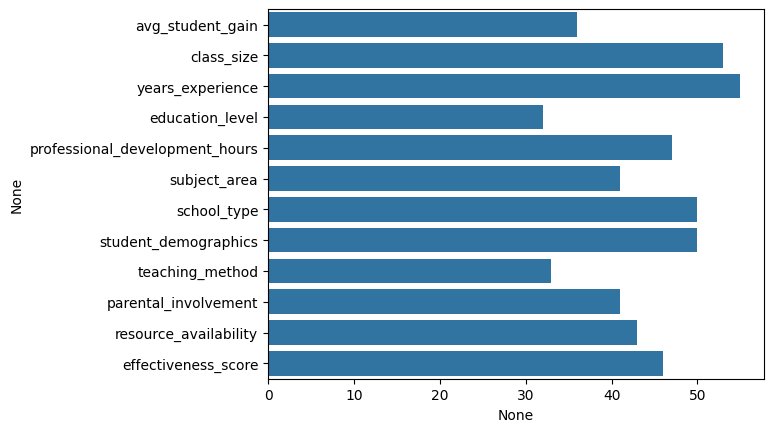

In [32]:
sns.barplot(x=df.isna().sum(),y=df.columns)
plt.show()        #visually compare quantities across categories.

In [33]:
# Impute numerical columns with median
num_cols = df.select_dtypes(include=['float64']).columns
imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

In [34]:
# Impute categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

In [35]:
print("\nAfter Imputation Missing Values:")
print(df.isna().sum())


After Imputation Missing Values:
avg_student_gain                  0
class_size                        0
years_experience                  0
education_level                   0
professional_development_hours    0
subject_area                      0
school_type                       0
student_demographics              0
teaching_method                   0
parental_involvement              0
resource_availability             0
effectiveness_score               0
dtype: int64


In [36]:
# 3. Clean the dataset
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print("\nData after cleaning:")
print(df.describe())


Data after cleaning:
       avg_student_gain   class_size  years_experience  \
count       1000.000000  1000.000000       1000.000000   
mean          15.125674    27.384000         17.859843   
std            5.626628     9.917606          9.535707   
min            5.039453    10.000000          1.004599   
25%           10.224938    19.000000          9.797022   
50%           15.031277    28.000000         17.973276   
75%           19.816599    35.250000         25.668497   
max           24.973376    44.000000         34.981142   

       professional_development_hours  effectiveness_score  
count                     1000.000000          1000.000000  
mean                        49.110424             5.575656  
std                         28.321245             2.508934  
min                          0.120306             1.020750  
25%                         24.640385             3.520222  
50%                         48.561974             5.509603  
75%                         

In [37]:
# Encode categorical variables
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le          #convert categorical (text) data into numbers

In [38]:
# 4. EDA and Data Visualization
print("\nEDA and Visualizations:")


EDA and Visualizations:


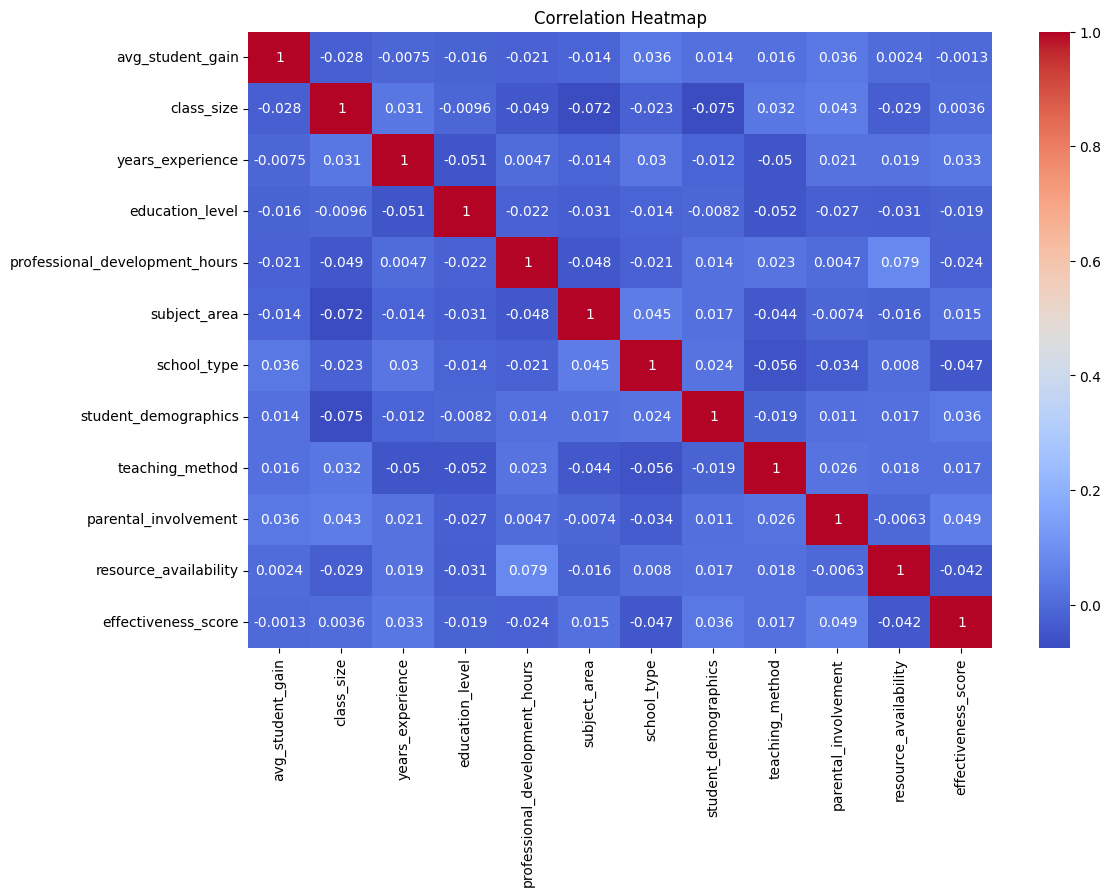

In [39]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()          #see how variables are related to each other

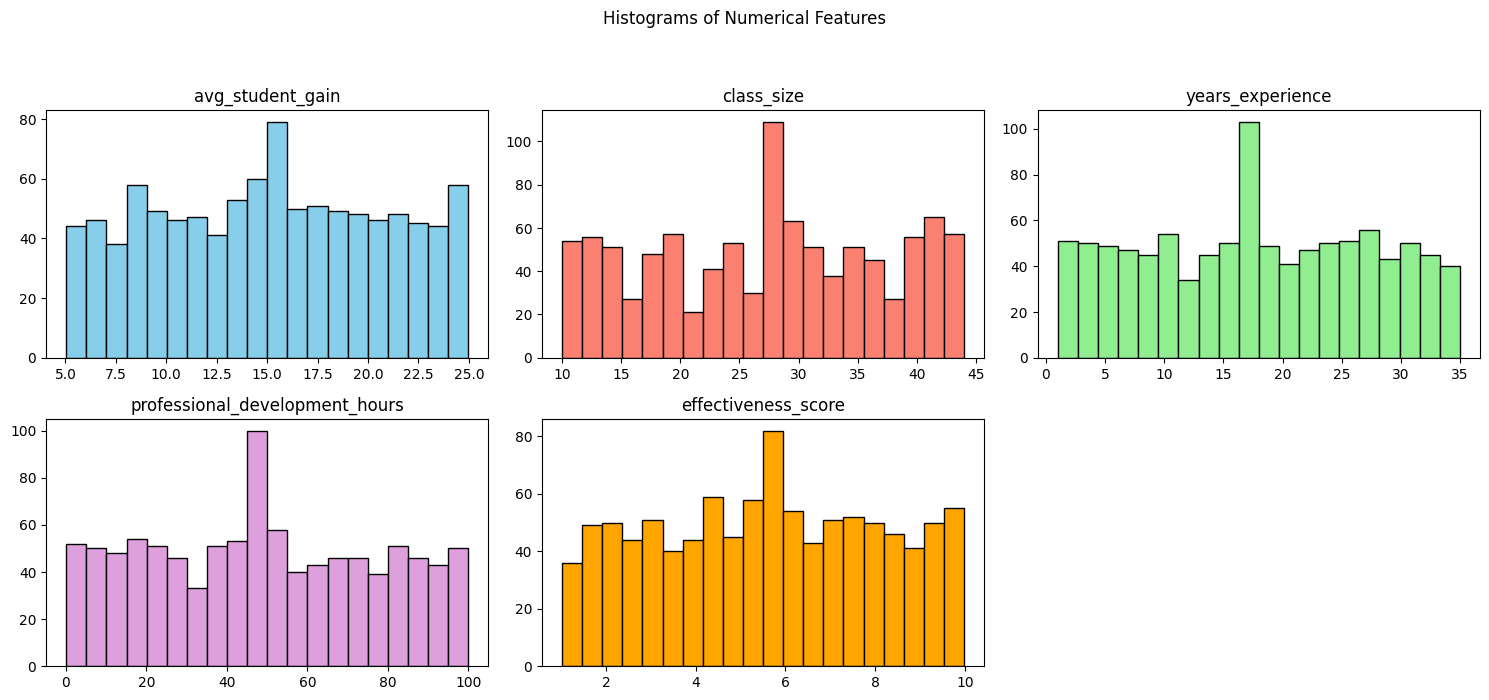

In [40]:
# Histograms for numerical features with different colors
colors = ['skyblue', 'salmon', 'lightgreen', 'plum', 'orange']

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)   # adjust grid if needed
    plt.hist(df[col], bins=20, color=colors[i % len(colors)], edgecolor='black')
    plt.title(col)

plt.suptitle('Histograms of Numerical Features')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()              # how the values are distributed.

/tmp/ipython-input-1918466483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


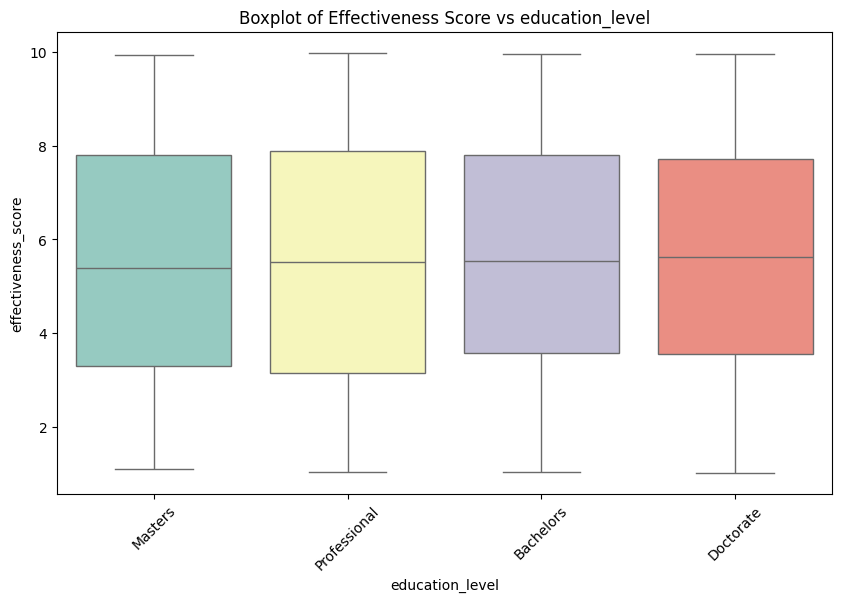

/tmp/ipython-input-1918466483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


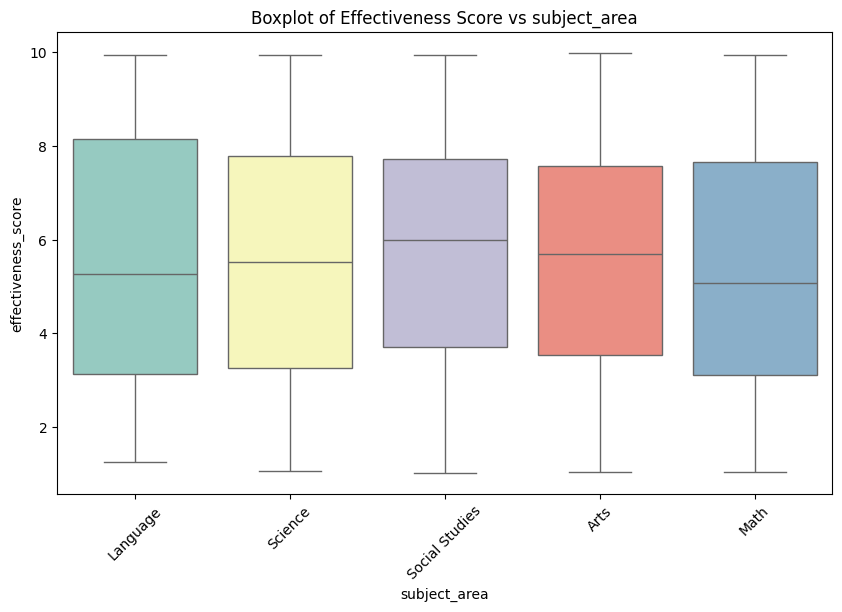

/tmp/ipython-input-1918466483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


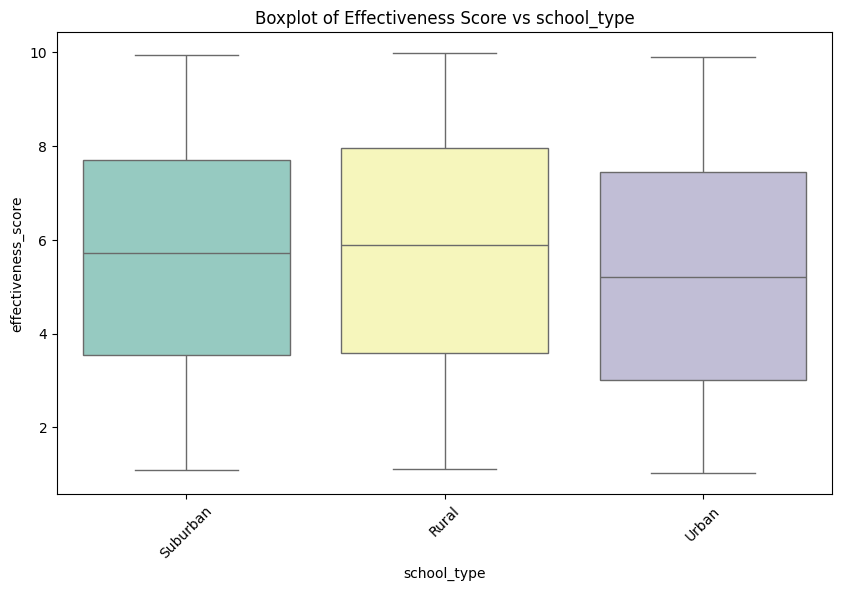

/tmp/ipython-input-1918466483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


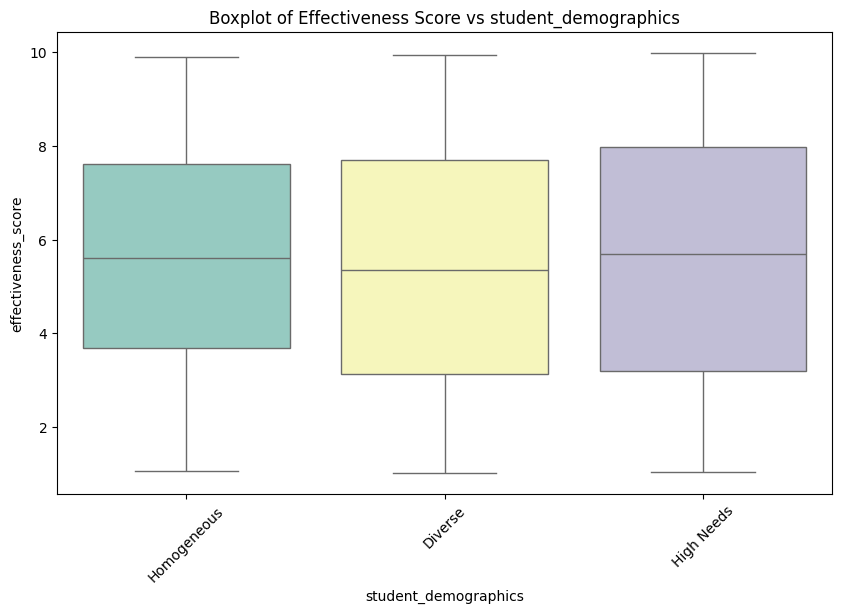

/tmp/ipython-input-1918466483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


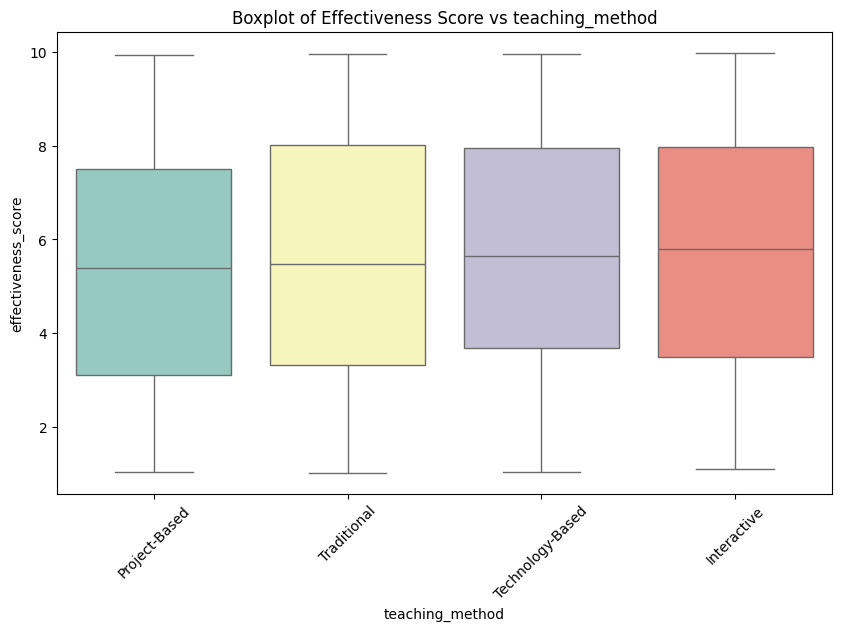

/tmp/ipython-input-1918466483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


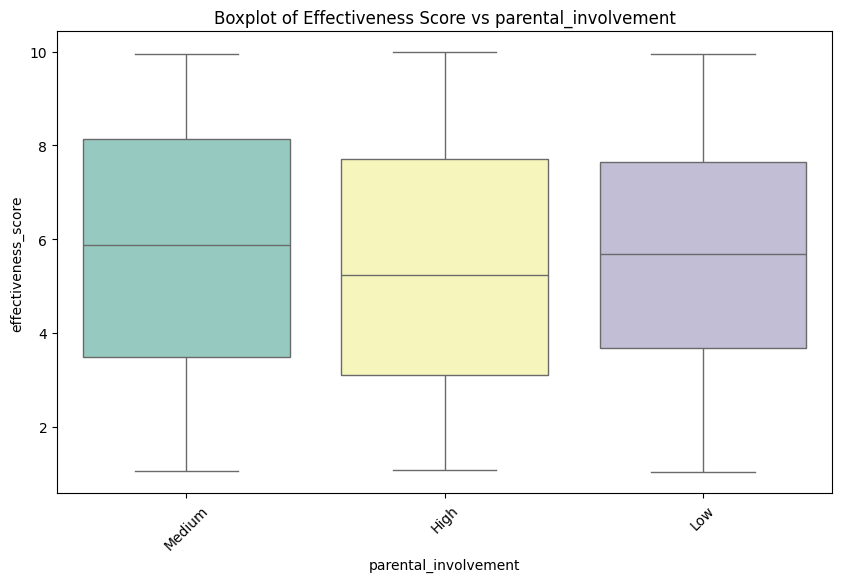

/tmp/ipython-input-1918466483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


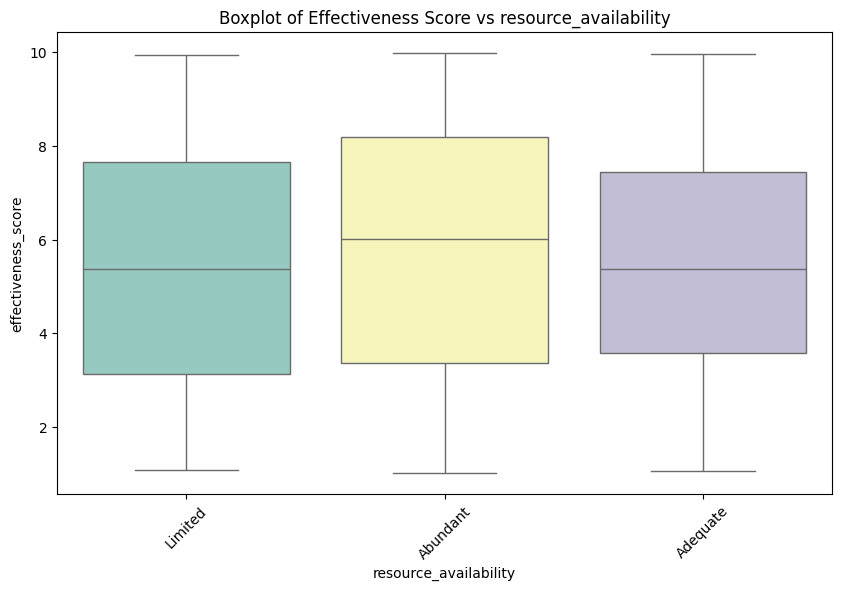

In [41]:
# Boxplots for effectiveness_score vs categorical (original categories)
original_df = pd.read_csv('teacher_effectiveness.csv')  # Reload original categorical data

for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x=original_df[col],
        y=original_df['effectiveness_score'],
        palette='Set3'   # different colors for each category
    )
    plt.title(f'Boxplot of Effectiveness Score vs {col}')
    plt.xticks(rotation=45)
    plt.show()       #compare teacher effectiveness scores across different categories

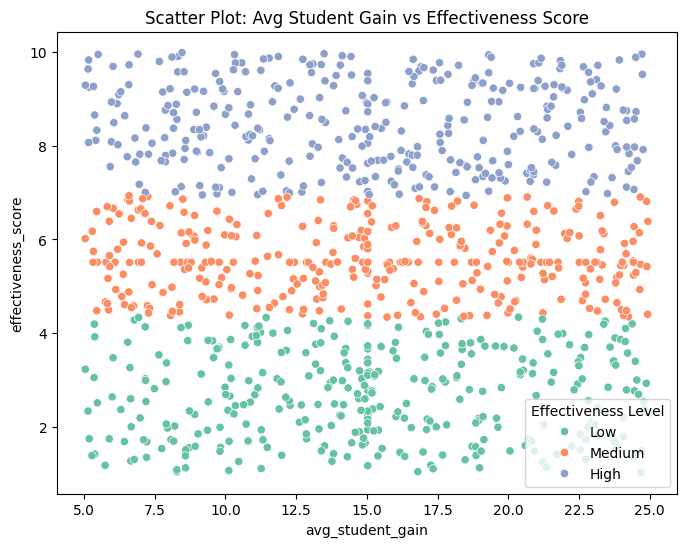

In [42]:
# Create effectiveness categories
df['effectiveness_level'] = pd.qcut(
    df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Scatter plot with different colors
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['avg_student_gain'],
    y=df['effectiveness_score'],
    hue=df['effectiveness_level'],
    palette='Set2'
)

plt.title('Scatter Plot: Avg Student Gain vs Effectiveness Score')
plt.legend(title='Effectiveness Level')
plt.show()   #to see the relationship between two numerical variables.

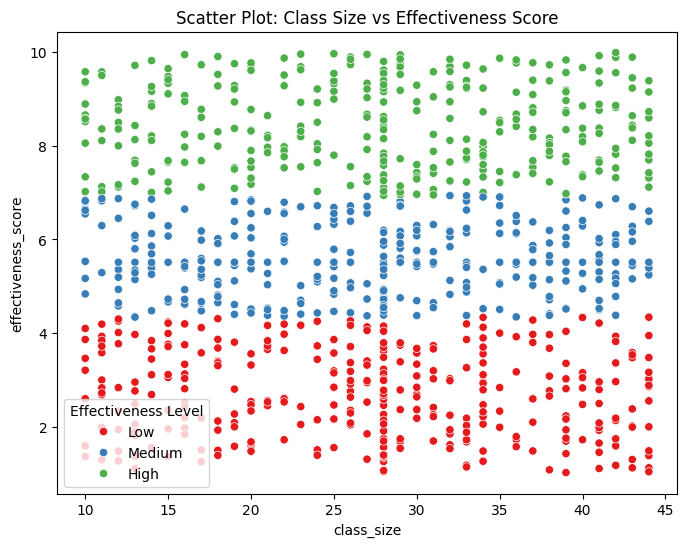

In [43]:
# Create effectiveness categories
df['effectiveness_level'] = pd.qcut(
    df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Scatter plot with different colors
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['class_size'],
    y=df['effectiveness_score'],
    hue=df['effectiveness_level'],
    palette='Set1'
)

plt.title('Scatter Plot: Class Size vs Effectiveness Score')
plt.legend(title='Effectiveness Level')
plt.show()


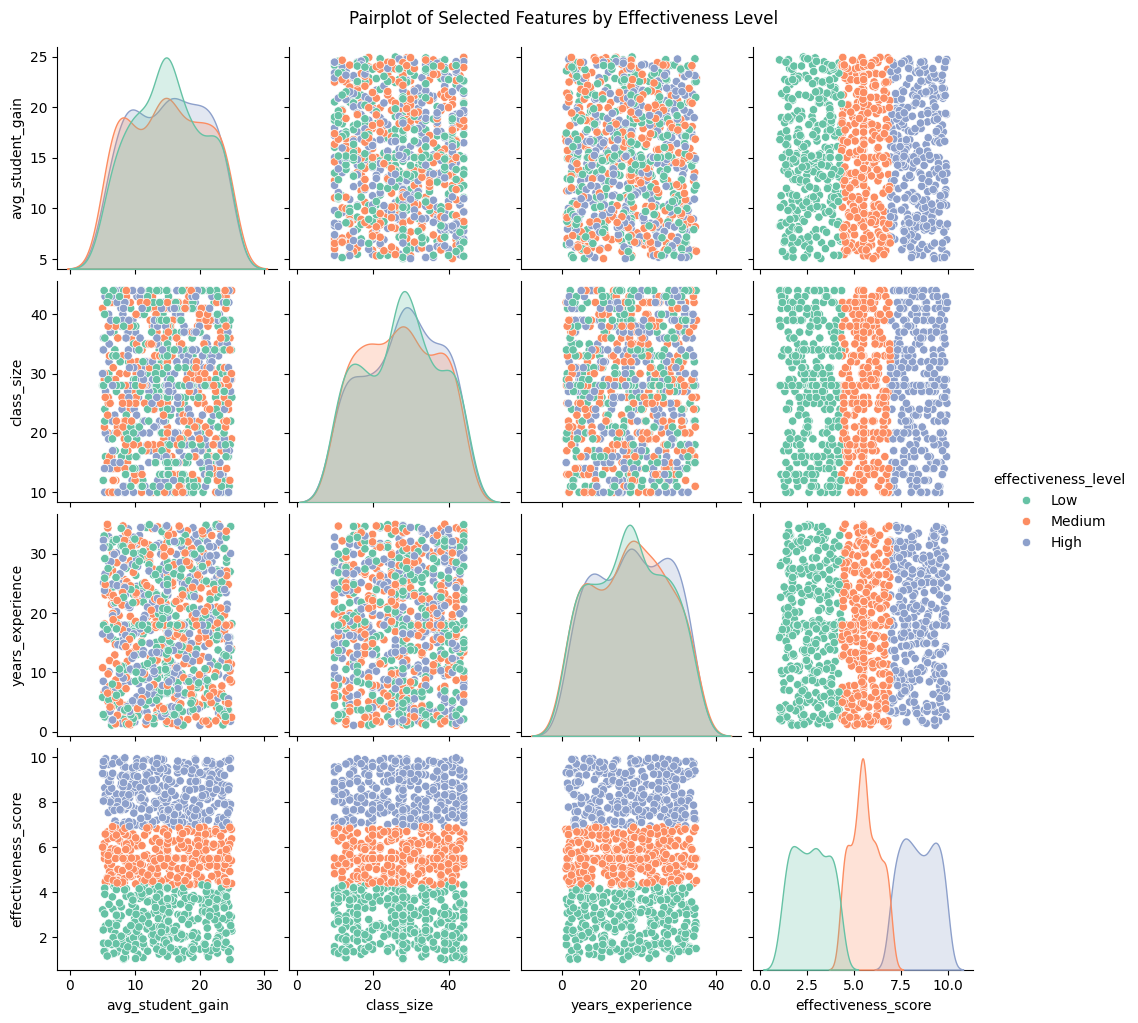

In [44]:
# Create categories for effectiveness score
df['effectiveness_level'] = pd.qcut(
    df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Pairplot with different colors
sns.pairplot(
    df[['avg_student_gain', 'class_size', 'years_experience', 'effectiveness_score', 'effectiveness_level']],
    hue='effectiveness_level',
    palette='Set2'
)

plt.suptitle('Pairplot of Selected Features by Effectiveness Level', y=1.02)
plt.show()         #relationships between multiple numerical variables at the same time.


In [45]:
# Prepare data for modeling
X = df.drop('effectiveness_score', axis=1)
y_reg = df['effectiveness_score']  # For regression

In [46]:
# Bin the target for classification (e.g., low: <4, medium: 4-7, high: >7)
bins = [0, 4, 7, 10]
labels = [0, 1, 2]  # 0: low, 1: medium, 2: high
y_class = pd.cut(y_reg, bins=bins, labels=labels)

In [47]:
# Split data
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [49]:
# Scale features
scaler = StandardScaler()

# Drop the 'effectiveness_level' column if it exists and is not numeric
if 'effectiveness_level' in X_train.columns:
    X_train = X_train.drop('effectiveness_level', axis=1)
if 'effectiveness_level' in X_test.columns:
    X_test = X_test.drop('effectiveness_level', axis=1)
if 'effectiveness_level' in X_train_class.columns:
    X_train_class = X_train_class.drop('effectiveness_level', axis=1)
if 'effectiveness_level' in X_test_class.columns:
    X_test_class = X_test_class.drop('effectiveness_level', axis=1)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train_class = scaler.fit_transform(X_train_class)  # Reuse scaler if same
X_test_class = scaler.transform(X_test_class)

In [50]:
# 5. Different types of regression
print("\nRegression Models:")


Regression Models:


In [51]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train_reg)
y_pred_lr = lr.predict(X_test)
print("Linear Regression - MSE:", mean_squared_error(y_test_reg, y_pred_lr))
print("Linear Regression - R2:", r2_score(y_test_reg, y_pred_lr))

Linear Regression - MSE: 5.720196767339427
Linear Regression - R2: -0.007574364506575559


In [52]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train_reg)
y_pred_ridge = ridge.predict(X_test)
print("Ridge Regression - MSE:", mean_squared_error(y_test_reg, y_pred_ridge))
print("Ridge Regression - R2:", r2_score(y_test_reg, y_pred_ridge))

Ridge Regression - MSE: 5.720076672476898
Ridge Regression - R2: -0.0075532106005624655


In [53]:
# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf = rf_reg.predict(X_test)
print("Random Forest Regressor - MSE:", mean_squared_error(y_test_reg, y_pred_rf))
print("Random Forest Regressor - R2:", r2_score(y_test_reg, y_pred_rf))

Random Forest Regressor - MSE: 6.3851058520815505
Random Forest Regressor - R2: -0.12469364829395801


In [54]:
# 6. Different types of conventional classification
print("\nClassification Models:")


Classification Models:


In [55]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_class, y_train_class)
y_pred_log = log_reg.predict(X_test_class)
print("Logistic Regression - Accuracy:", accuracy_score(y_test_class, y_pred_log))
print(classification_report(y_test_class, y_pred_log))    # to classify outcomes

Logistic Regression - Accuracy: 0.35
              precision    recall  f1-score   support

           0       0.30      0.21      0.25        61
           1       0.40      0.46      0.43        84
           2       0.31      0.33      0.32        55

    accuracy                           0.35       200
   macro avg       0.33      0.33      0.33       200
weighted avg       0.34      0.35      0.34       200



In [56]:
# Support Vector Machine Classifier
svm = SVC(kernel='rbf')
svm.fit(X_train_class, y_train_class)
y_pred_svm = svm.predict(X_test_class)
print("SVM - Accuracy:", accuracy_score(y_test_class, y_pred_svm))
print(classification_report(y_test_class, y_pred_svm))

SVM - Accuracy: 0.32
              precision    recall  f1-score   support

           0       0.19      0.15      0.17        61
           1       0.41      0.44      0.43        84
           2       0.29      0.33      0.31        55

    accuracy                           0.32       200
   macro avg       0.30      0.31      0.30       200
weighted avg       0.31      0.32      0.31       200



In [57]:
# Random Forest Classifier
rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
rf_class.fit(X_train_class, y_train_class)
y_pred_rf_class = rf_class.predict(X_test_class)
print("Random Forest Classifier - Accuracy:", accuracy_score(y_test_class, y_pred_rf_class))
print(classification_report(y_test_class, y_pred_rf_class))

Random Forest Classifier - Accuracy: 0.37
              precision    recall  f1-score   support

           0       0.26      0.23      0.25        61
           1       0.43      0.46      0.45        84
           2       0.38      0.38      0.38        55

    accuracy                           0.37       200
   macro avg       0.36      0.36      0.36       200
weighted avg       0.36      0.37      0.37       200



In [58]:
# 7. Classification using neural networks
print("\nNeural Network Classification:")


Neural Network Classification:


In [59]:
# Sklearn MLP
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp.fit(X_train_class, y_train_class)
y_pred_mlp = mlp.predict(X_test_class)
print("MLP Classifier - Accuracy:", accuracy_score(y_test_class, y_pred_mlp))
print(classification_report(y_test_class, y_pred_mlp))

MLP Classifier - Accuracy: 0.33
              precision    recall  f1-score   support

           0       0.26      0.26      0.26        61
           1       0.44      0.37      0.40        84
           2       0.28      0.35      0.31        55

    accuracy                           0.33       200
   macro avg       0.33      0.33      0.32       200
weighted avg       0.34      0.33      0.33       200



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [60]:
# TensorFlow Neural Network
model = Sequential()
model.add(tf.keras.Input(shape=(X_train_class.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 3 classes

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_class, y_train_class.astype(int), epochs=50, batch_size=32, validation_split=0.2, verbose=0)

loss, accuracy = model.evaluate(X_test_class, y_test_class.astype(int))
print("TensorFlow NN - Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3094 - loss: 1.2677  
TensorFlow NN - Accuracy: 0.3050000071525574


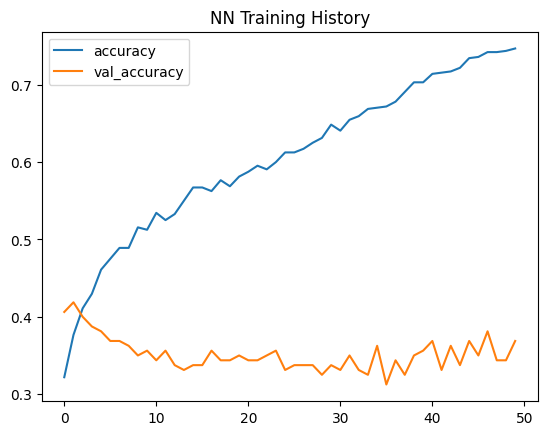

In [61]:
# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('NN Training History')
plt.legend()
plt.show()

Deployment of the project

In [62]:

!pip install gradio scikit-learn pandas


In [63]:
import pandas as pd
import gradio as gr

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor


In [64]:
# Load dataset
df = pd.read_csv("teacher_effectiveness.csv")

X = df.drop("effectiveness_score", axis=1)
y = df["effectiveness_score"]

# Impute missing values in y using the median strategy
from sklearn.impute import SimpleImputer
y = SimpleImputer(strategy='median').fit_transform(y.values.reshape(-1, 1)).flatten()

num_features = [
    "avg_student_gain",
    "class_size",
    "years_experience",
    "professional_development_hours"
]

cat_features = [
    "education_level",
    "subject_area",
    "school_type",
    "student_demographics",
    "teaching_method",
    "parental_involvement",
    "resource_availability"
]

# Pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

model.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['avg_student_gain',
                                                   'class_size',
                                                   'years_experience',
                                                   'professional_development_hours']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['education_level',
                                                   'subject_area',
                                                   'school_type',
                                                   'student_demographics',
                                                   'teaching_method',
                                                   'parental_involvement',
                                                   'resource_availability'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [65]:
def format_category_message(category):
    if category == "Low":
        return (
            "Low\n\n"
            "Teaching effectiveness needs improvement.\n\n"
            "Suggestions:\n"
            "- Increase professional development hours\n"
            "- Use interactive teaching methods\n"
            "- Improve student engagement\n"
            "- Encourage parental involvement\n"
            "- Improve resource availability"
        )
    elif category == "Medium":
        return (
            "Medium\n\n"
            "Teaching effectiveness is satisfactory.\n"
            "Keep it up and continue improving your teaching strategies."
        )
    else:  # High
        return (
            "High\n\n"
            "Excellent teaching effectiveness!\n"
            "Great job—your students are achieving strong outcomes."
        )


def predict_with_message(*inputs):
    score, category = predict_effectiveness(*inputs)
    message = format_category_message(category)
    return score, message


In [66]:
def ai_teacher_bot(user_message, effectiveness_score, effectiveness_category):
    # This is a placeholder function for the AI assistant.
    # You can expand this logic to provide more sophisticated responses
    # based on the user's query and the predicted effectiveness.

    if effectiveness_score is None:
        response = "Please predict an effectiveness score first."
    elif "improve" in user_message.lower():
        response = f"To improve {effectiveness_category} effectiveness, consider these suggestions: {effectiveness_category} Effectiveness. Suggestions: - Increase professional development hours - Use interactive teaching methods - Improve student engagement - Encourage parental involvement - Improve resource availability."
    else:
        response = f"Currently, the predicted effectiveness is {effectiveness_category} with a score of {effectiveness_score:.2f}. How else can I help?"

    return [[user_message, response]]

In [68]:
import gradio as gr
import numpy as np

# -----------------------------
# Dummy model prediction (replace with your trained model)
# -----------------------------
def mock_model_predict(features):
    # Simulated score between 1 and 5
    score = (
        0.03 * features[0] +        # avg_student_gain
        0.02 * features[2] +        # years_experience
        0.01 * features[3] -        # professional development
        0.02 * features[1]          # class_size
    ) / 10
    return np.clip(score, 1, 5)


# -----------------------------
# Prediction function (FIXED)
# -----------------------------
def predict_with_message(
    avg_student_gain, class_size, years_experience,
    professional_development_hours, education_level,
    subject_area, school_type, student_demographics,
    teaching_method, parental_involvement, resource_availability
):

    # Categorical mappings
    edu_map = {"Bachelor": 1, "Master": 2, "PhD": 3}
    parent_map = {"Low": 1, "Medium": 2, "High": 3}
    resource_map = {"Limited": 1, "Moderate": 2, "Abundant": 3}
    method_map = {
        "Traditional": 1,
        "Interactive": 2,
        "Technology-Based": 2.5,
        "Project-Based": 3
    }

    # Normalize numerical inputs (0–1 range)
    avg_gain_norm = avg_student_gain / 100
    class_size_norm = 1 - (class_size / 60)   # smaller class = better
    experience_norm = years_experience / 40
    pd_norm = professional_development_hours / 200

    # Weighted score calculation
    score = (
        0.30 * avg_gain_norm +
        0.20 * experience_norm +
        0.15 * pd_norm +
        0.15 * class_size_norm +
        0.08 * (edu_map[education_level] / 3) +
        0.06 * (parent_map[parental_involvement] / 3) +
        0.06 * (resource_map[resource_availability] / 3)
    )

    # Scale to 1–5
    score = round(1 + score * 4, 2)

    # ✅ Correct category thresholds
    if score < 2.5:
        category = "LOW"
        message = "Teaching effectiveness is low. Consider improving teaching strategies and professional development."
    elif score < 3.5:
        category = "MEDIUM"
        message = "Teaching effectiveness is satisfactory. Continue improving your teaching methods."
    else:
        category = "HIGH"
        message = "Teaching effectiveness is excellent. Keep up the great work!"

    return score, f"{category}\n\n{message}"



# -----------------------------
# Gradio UI
# -----------------------------
with gr.Blocks(theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # 🎓 Teacher Effectiveness Score Estimation
    ### Using Student Outcomes & Class Size

    This web-based system predicts **teacher effectiveness**
    using student performance, experience, and classroom factors.
    """)

    with gr.Row():

        with gr.Column():
            avg_student_gain = gr.Slider(0, 100, 50, label="📈 Average Student Gain")
            class_size = gr.Slider(10, 60, 30, label="🏫 Class Size")
            years_experience = gr.Slider(0, 40, 10, label="👨‍🏫 Years of Experience")
            professional_development_hours = gr.Slider(
                0, 200, 50, label="📚 Professional Development Hours"
            )

        with gr.Column():
            education_level = gr.Dropdown(
                ["Bachelor", "Master", "PhD"], label="🎓 Education Level"
            )
            subject_area = gr.Dropdown(
                ["Math", "Science", "English", "Social Studies"],
                label="📘 Subject Area"
            )
            school_type = gr.Dropdown(
                ["Public", "Private", "Charter"], label="🏫 School Type"
            )
            student_demographics = gr.Dropdown(
                ["Homogeneous", "Diverse", "High Needs"],
                label="👥 Student Demographics"
            )

        with gr.Column():
            teaching_method = gr.Dropdown(
                ["Traditional", "Interactive", "Technology-Based", "Project-Based"],
                label="🧠 Teaching Method"
            )
            parental_involvement = gr.Dropdown(
                ["Low", "Medium", "High"], label="👪 Parental Involvement"
            )
            resource_availability = gr.Dropdown(
                ["Limited", "Moderate", "Abundant"],
                label="🛠 Resource Availability"
            )

            predict_btn = gr.Button("🔍 Predict Effectiveness", variant="primary")
            score_output = gr.Number(label="📊 Effectiveness Score")
            category_output = gr.Textbox(label="🏆 Effectiveness Category", lines=6)

    predict_btn.click(
        predict_with_message,
        inputs=[
            avg_student_gain,
            class_size,
            years_experience,
            professional_development_hours,
            education_level,
            subject_area,
            school_type,
            student_demographics,
            teaching_method,
            parental_involvement,
            resource_availability
        ],
        outputs=[score_output, category_output]
    )

    gr.Markdown("## 🤖 Teaching Effectiveness Assistant")
    chatbot = gr.Chatbot(height=250)
    user_msg = gr.Textbox(
        placeholder="Ask how to improve teaching effectiveness...",
        label="Ask the AI Assistant"
    )

    send_btn = gr.Button("Send")
    send_btn.click(
        ai_teacher_bot,
        inputs=[user_msg, score_output, category_output],
        outputs=chatbot
    )

app.launch(share=True)


/tmp/ipython-input-3614699425.py:77: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as app:
/tmp/ipython-input-3614699425.py:149: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(height=250)
/tmp/ipython-input-3614699425.py:149: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=250)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc8e542ab49e7af665.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
